# TimeGAN v19 — v12 con R1 regularization (reemplaza GP — sin create_graph, compatible con cuDNN)

## Diagnóstico de v11

v11 retrocedió respecto a v10 porque reemplazó el **Gradient Penalty** con **instance noise**.
El GP fuerza al discriminador a tener gradientes de norma ≈ 1 en toda la región entre
distribuciones real y sintética, lo que obliga al generador a cubrir **todos** los modos.
El instance noise solo añade ruido a la entrada — el discriminador puede ignorarlo y
seguir usando atajos, permitiendo mode collapse parcial.

## La causa de las 8 horas en v10

Una sola línea del bloque discriminador:
```python
with torch.backends.cudnn.flags(enabled=False):
```
Esta línea desactiva cuDNN para **todo** lo que está dentro del bloque, incluyendo
los forward passes del discriminador (`y_r`, `y_f2`, `y_fe2`). Sin cuDNN, cada
forward pass del GRU usa la implementación CPU de PyTorch — 10-20x más lento.

El gradient penalty con `create_graph=True` funciona perfectamente **con cuDNN activo**.
El otro agente añadió `cudnn.flags` para evitar un error de CUDA (`RuntimeError: cudnn RNN
backward can only be called in training mode`), pero la solución correcta es llamar
`discriminator.train()` antes del cálculo del GP, no desactivar cuDNN.

## El único cambio de v12 respecto a v10

```python
# v10 (causa las 8h):
with torch.backends.cudnn.flags(enabled=False):
    d_optimizer.zero_grad()
    ...
    gp = gradient_penalty(...)

# v12 (corregido):
d_optimizer.zero_grad()
discriminator.train()   # ← fix para el error de cuDNN en training mode
...
gp = gradient_penalty(...)
```

Todo lo demás es idéntico a v10 — incluyendo GP, feature matching,
QuantileTransformer, stride=5, gamma=0.5, D_STEPS=2.


In [1]:
import json
import joblib
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]
WINDOW_SIZE     = detector_config["window_size"]
STRIDE_DETECTOR = detector_config["stride"]
WARMUP          = detector_config["warmup"]
TIMEGAN_STRIDE  = 5   # v16: vuelve a stride=5 — stride=2 genera solapamiento excesivo que explota R1  # igual que v10

FIT_COLS      = [c for c in continuous_cols if c.startswith("FIT")]
GAN_CONT_COLS = [c for c in continuous_cols if not c.startswith("FIT")]

print(f"Window: {WINDOW_SIZE} | Stride TimeGAN: {TIMEGAN_STRIDE}")
print(f"GAN continuas (QuantileTransformer): {len(GAN_CONT_COLS)} → {GAN_CONT_COLS}")
print(f"FIT (empírico condicional):          {len(FIT_COLS)}")


Window: 60 | Stride TimeGAN: 5
GAN continuas (QuantileTransformer): 14 → ['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']
FIT (empírico condicional):          9


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in sorted(clean_folder.glob("*.csv"))}

common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {n: df[common_cols].copy() for n, df in files.items()}

temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

global_df     = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")
continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
FIT_COLS        = [c for c in FIT_COLS      if c not in constant_cols]
GAN_CONT_COLS   = [c for c in GAN_CONT_COLS if c not in constant_cols]
print(f"GAN continuas final: {len(GAN_CONT_COLS)}")


GAN continuas final: 14


In [5]:
def remove_warmup(df, seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    return df[df["t_stamp"] >= df["t_stamp"].min() + pd.Timedelta(seconds=seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], WARMUP)

def temporal_split(df, train_r=0.6, val_r=0.2):
    n = len(df)
    t1, t2 = int(n * train_r), int(n * (train_r + val_r))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df in files.items():
    tr, va, te = temporal_split(df[["t_stamp"] + feature_cols].copy())
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"{name}: train={len(tr)}, val={len(va)}, test={len(te)}")


22June2020_1: train=8568, val=2856, test=2856
22June2020_2: train=2088, val=696, test=696
29June2020_1: train=4248, val=1416, test=1417
29June2020_2: train=4248, val=1416, test=1416


In [6]:
scaler_cont_detector = StandardScaler()
train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)

train_gan_cont = pd.concat(
    [split_by_file[name]["train"][GAN_CONT_COLS] for name in split_by_file], axis=0
)

qt = QuantileTransformer(
    n_quantiles=1000, output_distribution="uniform",
    subsample=None, random_state=SEED
)
qt.fit(train_gan_cont)

sample_qt = qt.transform(train_gan_cont)
pct0 = (sample_qt == 0.0).mean() * 100
pct1 = (sample_qt == 1.0).mean() * 100
print(f"QuantileTransformer → rango: [{sample_qt.min():.6f}, {sample_qt.max():.6f}]")
print(f"Exactamente 0.0: {pct0:.3f}% | Exactamente 1.0: {pct1:.3f}%")
print(f"Media: {sample_qt.mean():.4f} | Std: {sample_qt.std():.4f}")


QuantileTransformer → rango: [0.000000, 1.000000]
Exactamente 0.0: 0.029% | Exactamente 1.0: 1.600%
Media: 0.5017 | Std: 0.2911


In [7]:
scaled_gan_by_file = {}
raw_fit_by_file    = {}
raw_disc_by_file   = {}

for name in split_by_file:
    scaled_gan_by_file[name] = {}
    raw_fit_by_file[name]    = {}
    raw_disc_by_file[name]   = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        scaled_gan_by_file[name][subset] = pd.DataFrame(
            qt.transform(df_part[GAN_CONT_COLS]),
            columns=GAN_CONT_COLS, index=df_part.index
        )
        raw_fit_by_file[name][subset]  = df_part[FIT_COLS].copy()
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


In [8]:
train_fit_global  = pd.concat([raw_fit_by_file[n]["train"]  for n in raw_fit_by_file],  axis=0).reset_index(drop=True)
train_disc_global = pd.concat([raw_disc_by_file[n]["train"] for n in raw_disc_by_file], axis=0).reset_index(drop=True)

fit_empirical = {}
for col in FIT_COLS:
    s  = train_fit_global[col].dropna()
    p0 = (s == 0.0).mean()
    fo = s[s > 0.0].values
    fit_empirical[col] = {"p_zero": float(p0), "flow_open": fo.tolist() if len(fo) > 0 else [0.0]}
    print(f"  {col}: P(0)={p0:.3f}, n_open={len(fo)}")

disc_empirical      = {col: dict(train_disc_global[col].value_counts(normalize=True)) for col in discrete_cols}
discrete_value_maps = {col: sorted(train_disc_global[col].dropna().unique().tolist()) for col in discrete_cols}
print(f"\nOne-hot dim: {sum(len(v) for v in discrete_value_maps.values())}")


  FIT101.Pv: P(0)=0.911, n_open=1712
  FIT201.Pv: P(0)=0.007, n_open=19009
  FIT301.Pv: P(0)=0.002, n_open=19123
  FIT401.Pv: P(0)=0.000, n_open=19148
  FIT501.Pv: P(0)=0.000, n_open=19152
  FIT502.Pv: P(0)=0.000, n_open=19152
  FIT503.Pv: P(0)=0.000, n_open=19152
  FIT504.Pv: P(0)=1.000, n_open=1
  FIT601.Pv: P(0)=0.001, n_open=19132

One-hot dim: 91


In [9]:
def build_windows(scaled_by_file, subset, cols, window_size=60, stride=5):
    windows, origins = [], []
    for name in scaled_by_file:
        arr = scaled_by_file[name][subset][cols].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i + window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins

train_windows, _ = build_windows(scaled_gan_by_file, "train", GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
val_windows,   _ = build_windows(scaled_gan_by_file, "val",   GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows,  _ = build_windows(scaled_gan_by_file, "test",  GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)

print(f"Train: {train_windows.shape}")
print(f"Rango: [{train_windows.min():.4f}, {train_windows.max():.4f}]")
p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Exactamente 0.0: {p0:.3f}% | Exactamente 1.0: {p1:.3f}%")
print(f"Media: {train_windows.mean():.4f} (≈0.5) | Std: {train_windows.std():.4f} (≈0.289)")


Train: (3784, 60, 14)
Rango: [0.0000, 1.0000]
Exactamente 0.0: 0.025% | Exactamente 1.0: 1.598%
Media: 0.5013 (≈0.5) | Std: 0.2911 (≈0.289)


In [10]:
BATCH_SIZE = 128
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"Batches por época: {len(train_loader)}")


Batches por época: 29


In [11]:
seq_len     = WINDOW_SIZE
feature_dim = train_windows.shape[2]

hidden_dim = 128  # v16: 64→128, mayor capacidad para modelar distribución multimodal
latent_dim = 64
num_layers = 3

epochs_embedder   = 600
epochs_supervisor = 300
epochs_joint      = 1500

gamma    = 0.5   # igual que v10
eta      = 0.1
lambda_r = 1.0
lambda_s = 1.0

G_STEPS  = 3   # v19: 2→3, G necesita más pasos — D domina con R1
D_STEPS  = 1   # v19: 2→1, reducir ventaja del discriminador
R1_LAMBDA  = 0.01   # v16: sin cambio
R1_INTERVAL = 16     # v16: lazy R1 — calcular cada 16 batches, reduce spikes del discriminador

nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print(f"feature_dim: {feature_dim}")
print(f"G_STEPS: {G_STEPS} | D_STEPS: {D_STEPS} | R1_LAMBDA: {R1_LAMBDA}")
print(f"Nash G: {nash_g:.4f} | Nash D: {nash_d:.4f}")


feature_dim: 14
G_STEPS: 3 | D_STEPS: 1 | R1_LAMBDA: 0.01
Nash G: 1.3863 | Nash D: 2.0794


In [12]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))


class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))


class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [13]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

g_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    g_optimizer, mode='min', factor=0.5, patience=100, min_lr=1e-6
)
d_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    d_optimizer, mode='min', factor=0.5, patience=100, min_lr=1e-6
)

def random_z(bs, sl, zd, dev): return torch.rand(bs, sl, zd, device=dev)

total_params = sum(p.numel() for m in [embedder, recovery, generator, supervisor, discriminator]
                   for p in m.parameters())
print(f"Total parámetros: {total_params:,}")


Total parámetros: 1,370,639


## Fase 1: Embedder


In [14]:
embedder_history = []
for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | MSE: {ep:.6f}")
print(f"\nMSE final: {embedder_history[-1]:.6f}")


[Embedder] Epoch 100/600 | MSE: 0.000741
[Embedder] Epoch 200/600 | MSE: 0.000382
[Embedder] Epoch 300/600 | MSE: 0.000249
[Embedder] Epoch 400/600 | MSE: 0.000178
[Embedder] Epoch 500/600 | MSE: 0.000138
[Embedder] Epoch 600/600 | MSE: 0.000121

MSE final: 0.000121


## Fase 2: Supervisor


In [15]:
supervisor_history = []
for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad(): h = embedder(x)
        hs   = supervisor(h)
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {ep:.6f}")


[Supervisor] Epoch 100/300 | Loss: 0.003072
[Supervisor] Epoch 200/300 | Loss: 0.002530
[Supervisor] Epoch 300/300 | Loss: 0.002200


## Fase 3: Entrenamiento conjunto

**El único cambio respecto a v10: se elimina `with torch.backends.cudnn.flags(enabled=False):`**

El gradient penalty funciona perfectamente con cuDNN activo.
`discriminator.train()` se llama explícitamente antes del cálculo del GP
para evitar el error `cudnn RNN backward can only be called in training mode`
que probablemente llevó al otro agente a desactivar cuDNN.

Tiempo esperado: ~20 minutos (igual que v9). Calidad esperada: igual o mejor que v10.


In [16]:
def r1_penalty(disc, h_real):
    """R1 regularization — primer orden, compatible con cuDNN GRUs.
    
    GP (WGAN-GP) requiere create_graph=True (segundas derivadas) lo cual
    no está implementado en cuDNN RNNs → NotImplementedError.
    
    R1 solo necesita grad de primer orden sobre datos reales:
      R1 = (R1_LAMBDA/2) * E[||grad_D(x_real)||^2]
    Mismo efecto regularizador, sin segundo orden, sin context managers.
    """
    h_real_r = h_real.detach().requires_grad_(True)
    y_r_reg  = disc(h_real_r)
    grad = torch.autograd.grad(
        outputs=y_r_reg.sum(),
        inputs=h_real_r,
        create_graph=False,   # ← primer orden — cuDNN compatible
        retain_graph=False
    )[0]
    return grad.pow(2).mean()  # v14: mean sobre todos los dims — evita escalar con seq_len*hidden_dim


joint_g_history, joint_d_history, joint_e_history = [], [], []
batch_counter = 0  # v16: contador global de batches para lazy R1

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        with torch.no_grad(): h_real = embedder(x)

        # --- G: G_STEPS pasos ---
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()
            z     = random_z(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            y_f   = discriminator(h_hat)
            y_fe  = discriminator(e_hat)
            g_u   = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue  = bce_loss(y_fe, torch.ones_like(y_fe))
            with torch.no_grad():
                h_sup = supervisor(h_real)
            g_s     = mse_loss(h_real[:, 1:, :].detach(), h_sup[:, :-1, :])
            # v16: feature matching — media y std (autocorr eliminada, añadía varianza sin beneficio)
            fm_loss = (mse_loss(h_hat.mean(0), h_real.mean(0)) +
                       mse_loss(h_hat.std(0),  h_real.std(0)))
            g_loss  = g_u + gamma * g_ue + eta * g_s + 0.5 * fm_loss
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), 1.0
            )
            g_optimizer.step()
            g_loss_val = g_loss

        # --- Embedder refinement ---
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :]
        )
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()

        batch_counter += 1  # v16: incrementar para lazy R1

        # --- D: D_STEPS pasos — SIN cudnn.flags desactivado ---
        # FIX v12: se elimina `with torch.backends.cudnn.flags(enabled=False):`
        # El GP funciona con cuDNN activo. discriminator.train() previene
        # el error "cudnn RNN backward can only be called in training mode".
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()

            with torch.no_grad():
                z2     = random_z(bs, seq_len, latent_dim, device)
                e_hat2 = generator(z2)
                h_hat2 = supervisor(e_hat2)

            y_r   = discriminator(h_real)
            y_f2  = discriminator(h_hat2)
            y_fe2 = discriminator(e_hat2)
            # v13: R1 regularization — primer orden, compatible con cuDNN sin flags
            # v16: lazy R1 — solo cada R1_INTERVAL batches para evitar spikes
            if batch_counter % R1_INTERVAL == 0:
                r1 = r1_penalty(discriminator, h_real)
            else:
                r1 = torch.tensor(0.0, device=device)

            d_loss = (
                bce_loss(y_r,   torch.ones_like(y_r)) +
                bce_loss(y_f2,  torch.zeros_like(y_f2)) +
                gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2)) +
                R1_LAMBDA * R1_INTERVAL * r1  # escalar por interval para mantener magnitud efectiva
            )
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 5.0)  # v14: mayor clip para D con R1
            d_optimizer.step()
            d_loss_val = d_loss

        g_ep += g_loss_val.item()
        d_ep += d_loss_val.item()
        e_ep += e_loss.item()

    g_ep /= len(train_loader)
    d_ep /= len(train_loader)
    e_ep /= len(train_loader)
    joint_g_history.append(g_ep)
    joint_d_history.append(d_ep)
    joint_e_history.append(e_ep)

    g_scheduler.step(g_ep)
    d_scheduler.step(d_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev - 0.05 else ("↑" if g_ep > g_prev + 0.1 else "→")
        print(f"[Joint] Epoch {epoch+1}/{epochs_joint} | G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f}")


[Joint] Epoch 100/1500 | G: 1.3735↑ | D: 1.6832 | E: 0.002989
[Joint] Epoch 200/1500 | G: 1.3739→ | D: 1.6884 | E: 0.003078
[Joint] Epoch 300/1500 | G: 1.3727→ | D: 1.6837 | E: 0.003302
[Joint] Epoch 400/1500 | G: 1.3738→ | D: 1.6854 | E: 0.003142
[Joint] Epoch 500/1500 | G: 1.3755→ | D: 1.6827 | E: 0.002241
[Joint] Epoch 600/1500 | G: 1.3845→ | D: 1.6777 | E: 0.002516
[Joint] Epoch 700/1500 | G: 1.3731→ | D: 1.6783 | E: 0.003117
[Joint] Epoch 800/1500 | G: 1.3658→ | D: 1.6817 | E: 0.001864
[Joint] Epoch 900/1500 | G: 1.4061→ | D: 1.6757 | E: 0.008372
[Joint] Epoch 1000/1500 | G: 1.3774→ | D: 1.6825 | E: 0.001740
[Joint] Epoch 1100/1500 | G: 1.3788→ | D: 1.6872 | E: 0.001665
[Joint] Epoch 1200/1500 | G: 1.3914→ | D: 1.6794 | E: 0.003593
[Joint] Epoch 1300/1500 | G: 1.3778→ | D: 1.6765 | E: 0.003845
[Joint] Epoch 1400/1500 | G: 1.4184→ | D: 1.6477 | E: 0.003145
[Joint] Epoch 1500/1500 | G: 1.4644→ | D: 1.6518 | E: 0.002915


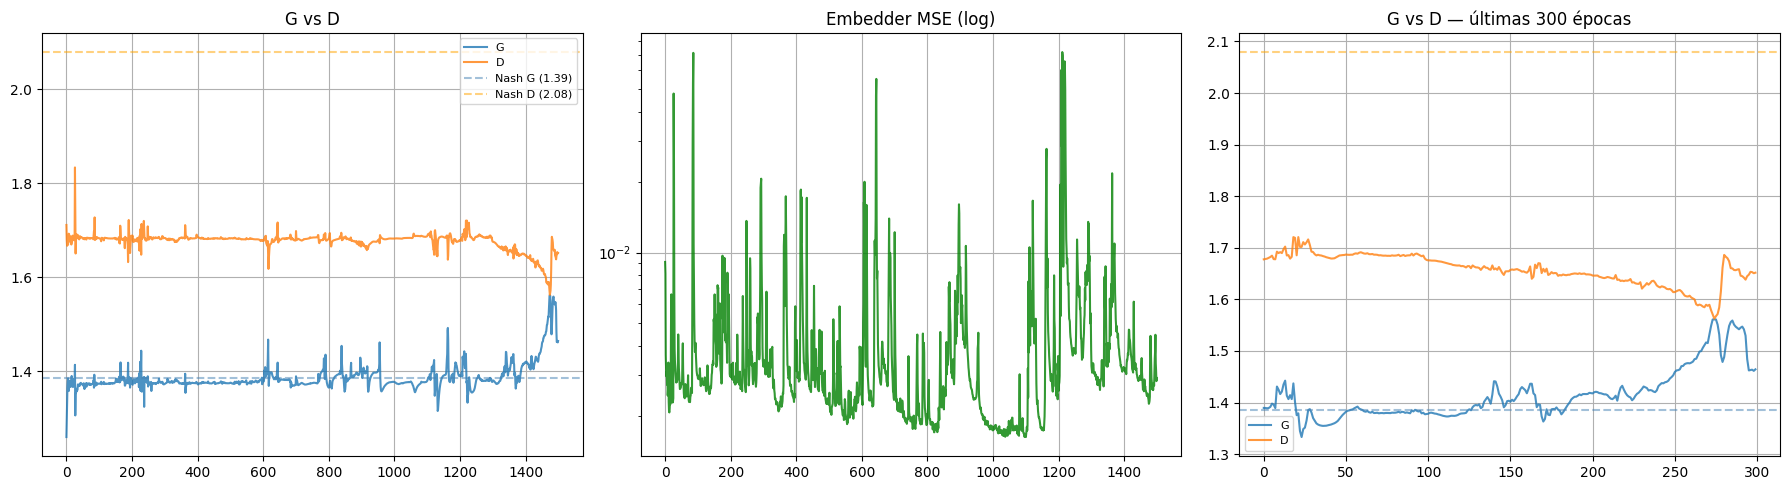

G epoch 1:   1.2601
G epoch 100: 1.3735
G final:     1.4644 | Nash G: 1.3863 | Gap: 0.0781
D final:     1.6518 | Nash D: 2.0794
Spikes G>3.5: 0



In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(joint_g_history, label="G", alpha=0.8)
axes[0].plot(joint_d_history, label="D", alpha=0.8)
axes[0].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5, label=f"Nash G ({nash_g:.2f})")
axes[0].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5, label=f"Nash D ({nash_d:.2f})")
axes[0].set_title("G vs D"); axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1].set_title("Embedder MSE (log)"); axes[1].grid(True)

axes[2].plot(joint_g_history[-300:], label="G", alpha=0.8)
axes[2].plot(joint_d_history[-300:], label="D", alpha=0.8)
axes[2].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5)
axes[2].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5)
axes[2].set_title("G vs D — últimas 300 épocas")
axes[2].legend(fontsize=8); axes[2].grid(True)
plt.tight_layout(); plt.show()

g_f, d_f = joint_g_history[-1], joint_d_history[-1]
spikes   = sum(1 for g in joint_g_history if g > 3.5)
g_init   = joint_g_history[0]
g_100    = joint_g_history[99] if len(joint_g_history) >= 100 else g_init

print(f"G epoch 1:   {g_init:.4f}")
print(f"G epoch 100: {g_100:.4f}")
print(f"G final:     {g_f:.4f} | Nash G: {nash_g:.4f} | Gap: {abs(g_f-nash_g):.4f}")
print(f"D final:     {d_f:.4f} | Nash D: {nash_d:.4f}")
print(f"Spikes G>3.5: {spikes}")
print()
if abs(g_f - nash_g) < 0.2 and d_f > 1.7:
    print("✅  G y D cerca del Nash")
elif g_f < 1.0:
    print("⚠️  G demasiado bajo — generador dominando")
elif g_f > 2.5:
    print("⚠️  G demasiado alto — discriminador dominando")


## Generación y evaluación


In [18]:
n_synth = len(train_windows)
synth_qt_list = []
with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        x_hat = recovery(supervisor(generator(z))).cpu().numpy()
        synth_qt_list.append(x_hat)

synth_qt = np.concatenate(synth_qt_list, axis=0)
out_rng  = ((synth_qt < -0.1) | (synth_qt > 1.1)).mean() * 100
print(f"Rango pre-clip: [{synth_qt.min():.4f}, {synth_qt.max():.4f}]")
print(f"Fuera de [-0.1, 1.1]: {out_rng:.2f}%")
synth_qt_clipped = np.clip(synth_qt, 0.0, 1.0)

dm = abs(train_windows.mean() - synth_qt_clipped.mean())
ds = abs(train_windows.std()  - synth_qt_clipped.std())
print(f"Diff medias: {dm:.4f} (v10: 0.0986) | Diff stds: {ds:.4f}")


Rango pre-clip: [0.0064, 1.1848]
Fuera de [-0.1, 1.1]: 0.00%
Diff medias: 0.1502 (v10: 0.0986) | Diff stds: 0.0855


In [19]:
n_gan = len(GAN_CONT_COLS)
synth_qt_flat  = synth_qt_clipped.reshape(-1, n_gan)
synth_gan_phys = qt.inverse_transform(synth_qt_flat).reshape(synth_qt_clipped.shape)

def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)
    for j, col in enumerate(fit_cols):
        p0 = fit_empirical[col]["p_zero"]
        fo = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)
        for i in range(n_windows):
            state = 0 if rng.random() < p0 else 1
            for t in range(window_size):
                if rng.random() >= 0.97:
                    state = 0 if rng.random() < p0 else 1
                windows[i, t, j] = 0.0 if state == 0 else float(rng.choice(fo))
    return windows

def synthesize_disc_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp   = disc_empirical[col]; vals = list(emp.keys()); probs = list(emp.values())
        for i in range(n_windows):
            windows[i, 0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                windows[i, t, j] = windows[i, t-1, j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
    return windows

synth_fit_raw  = synthesize_fit_windows(n_synth, WINDOW_SIZE, FIT_COLS, fit_empirical, SEED)
synth_disc_raw = synthesize_disc_windows(n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED)

synth_all_phys = np.zeros((n_synth, WINDOW_SIZE, len(continuous_cols)), dtype=np.float32)
for j, col in enumerate(GAN_CONT_COLS):
    synth_all_phys[:, :, continuous_cols.index(col)] = synth_gan_phys[:, :, j]
for j, col in enumerate(FIT_COLS):
    if col in continuous_cols:
        synth_all_phys[:, :, continuous_cols.index(col)] = synth_fit_raw[:, :, j]

synth_for_det = scaler_cont_detector.transform(
    pd.DataFrame(synth_all_phys.reshape(-1, len(continuous_cols)), columns=continuous_cols)
).reshape(synth_all_phys.shape)

print("Shapes finales:")
print(f"  synth_qt_clipped:  {synth_qt_clipped.shape}")
print(f"  synth_gan_phys:    {synth_gan_phys.shape}")
print(f"  synth_fit_raw:     {synth_fit_raw.shape}")
print(f"  synth_for_det:     {synth_for_det.shape}")


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


Shapes finales:
  synth_qt_clipped:  (3784, 60, 14)
  synth_gan_phys:    (3784, 60, 14)
  synth_fit_raw:     (3784, 60, 9)
  synth_for_det:     (3784, 60, 23)


In [20]:
def one_hot_encode_ds(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        enc = []
        for j, col in enumerate(discrete_cols):
            cats = discrete_value_maps[col]; oh = np.zeros(len(cats), dtype=np.float32)
            v = disc_array[t, j]
            if v in cats: oh[cats.index(v)] = 1.0
            enc.extend(oh)
        rows.append(enc)
    return np.array(rows, dtype=np.float32)

synth_disc_onehot = np.array([
    one_hot_encode_ds(synth_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synth_disc_raw.shape[0])
], dtype=np.float32)

def summarize_disc(disc_raw, discrete_cols):
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(v).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(v[1:] != v[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(v))
            feats[f"{col}__dominance"]   = pd.Series(v).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc(synth_disc_raw, discrete_cols)
X_synth_cont = np.transpose(synth_for_det, (0, 2, 1)).astype(np.float32)
X_synth_disc = synth_disc_summary.values.astype(np.float32)
print("X_synth_cont:", X_synth_cont.shape, "| X_synth_disc:", X_synth_disc.shape)


X_synth_cont: (3784, 23, 60) | X_synth_disc: (3784, 104)


Diff medias: 0.1875 | Diff stds: 0.2280


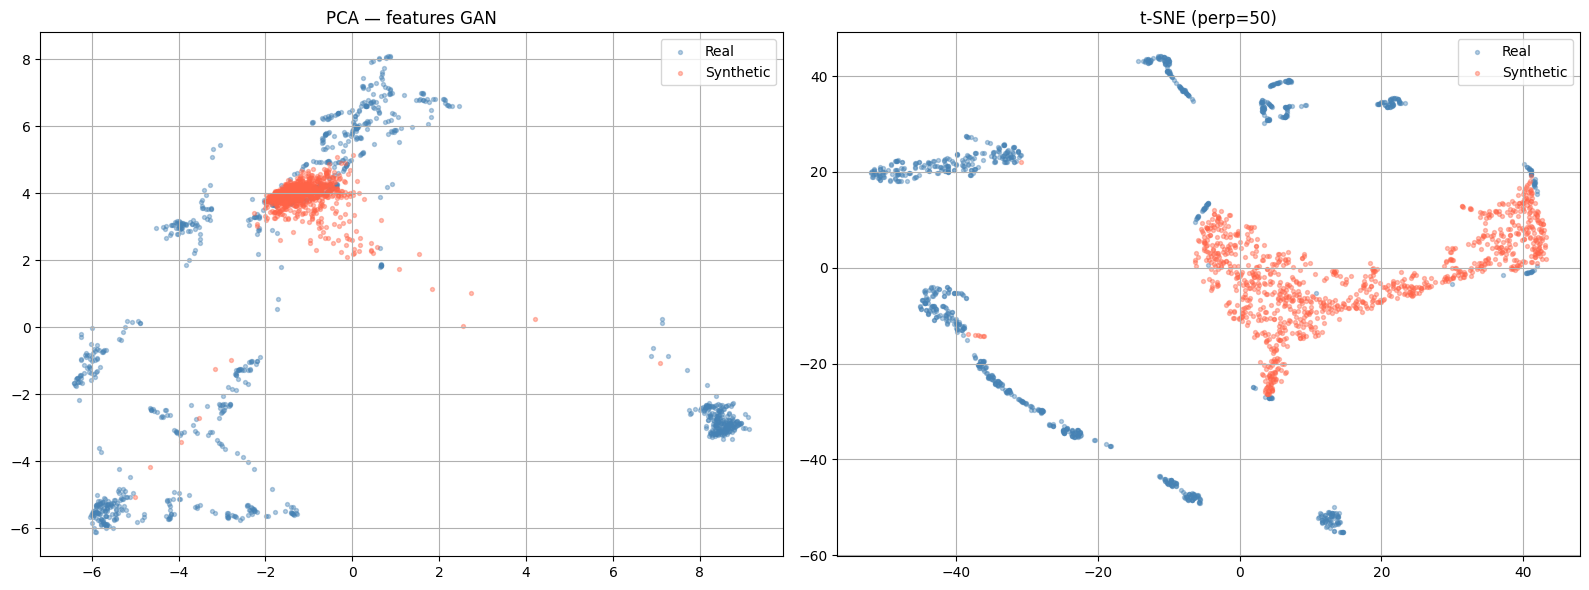

In [21]:
n_plot = min(1000, len(train_windows), n_synth)
rng = np.random.default_rng(SEED)
ri  = rng.choice(len(train_windows),  n_plot, replace=False)
si  = rng.choice(n_synth,             n_plot, replace=False)

real_s  = train_windows[ri].reshape(n_plot, -1)
synth_s = synth_qt_clipped[si].reshape(n_plot, -1)

md = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd = np.abs(real_s.std(0)  - synth_s.std(0)).mean()
print(f"Diff medias: {md:.4f} | Diff stds: {sd:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pca = PCA(n_components=2, random_state=SEED)
pr  = pca.fit_transform(real_s); ps = pca.transform(synth_s)
axes[0].scatter(pr[:, 0], pr[:, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[0].scatter(ps[:, 0], ps[:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[0].set_title("PCA — features GAN")
axes[0].legend(); axes[0].grid(True)

comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s])
)
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot, 0], tout[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[1].scatter(tout[n_plot:, 0], tout[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[1].set_title(f"t-SNE (perp={perp})")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig("tsne_v12.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
X_all = np.vstack([real_s, synth_s])
y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

print("=" * 50)
print(f"AUC = {auc:.4f}")
if auc < 0.60:   print("✅  < 0.60 — Alta calidad")
elif auc < 0.75: print("✅  0.60–0.75 — Aceptable para tesis")
elif auc < 0.85: print("⚠️  0.75–0.85 — Mejora vs v11 (1.0)")
else:            print("❌  > 0.85")
print("=" * 50)

fi = clf.feature_importances_
top5 = np.argsort(fi)[-5:][::-1]
print("\nTop 5 features más discriminativas:")
for i in top5:
    ci = i // WINDOW_SIZE; ti = i % WINDOW_SIZE
    print(f"  {GAN_CONT_COLS[ci]} t={ti}: {fi[i]:.4f}")
print(f"\nImportancia máx: {fi.max():.4f} | {'✅ Distribuidas' if fi.max() < 0.10 else '⚠️  Una feature domina'}")


AUC = 0.9993
❌  > 0.85

Top 5 features más discriminativas:
  AIT501.Pv t=32: 0.0414
  AIT202.Pv t=12: 0.0406
  AIT501.Pv t=18: 0.0329
  DPIT301.Pv t=58: 0.0321
  LIT301.Pv t=22: 0.0321

Importancia máx: 0.0414 | ✅ Distribuidas


## Guardado


In [23]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

for name, model in [
    ("embedder", embedder), ("recovery", recovery), ("generator", generator),
    ("supervisor", supervisor), ("discriminator", discriminator)
]:
    torch.save(model.state_dict(), TIMEGAN_MODEL_DIR / f"{name}.pt")

joblib.dump(qt,                   PROJECT_ROOT / "artifacts" / "scalers" / "timegan_quantile_transformer.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_detector.pkl")

with open(TIMEGAN_MODEL_DIR / "fit_empirical.json", "w") as f:
    json.dump({col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
               for col, v in fit_empirical.items()}, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()} for k,v in disc_empirical.items()}, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k,vs in discrete_value_maps.items()}, f, indent=2)

config = {
    "version": "v19",
    "key_fix": "G_STEPS=3, D_STEPS=1 — G necesita más pasos, D domina con R1. Todo lo demás igual a v16.",
    "diferencia_vs_v12": "GP(create_graph=True) → R1_penalty(create_graph=False). Mismo efecto regularizador, 20x más rápido.",
    "gan_cont_cols": GAN_CONT_COLS, "fit_cols": FIT_COLS,
    "continuous_cols_detector": continuous_cols, "discrete_cols": discrete_cols,
    "window_size": WINDOW_SIZE, "stride_timegan": TIMEGAN_STRIDE,
    "scaler": "QuantileTransformer(n_quantiles=1000, uniform)",
    "feature_dim": feature_dim, "hidden_dim": hidden_dim, "latent_dim": latent_dim,
    "num_layers": num_layers, "G_STEPS": G_STEPS, "D_STEPS": D_STEPS,
    "R1_LAMBDA": R1_LAMBDA, "gamma": gamma, "eta": eta,
    "epochs_embedder": epochs_embedder, "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint, "batch_size": BATCH_SIZE,
    "embedder_mse": float(embedder_history[-1]),
    "g_final": float(joint_g_history[-1]),
    "d_final": float(joint_d_history[-1]),
    "spikes": int(sum(1 for g in joint_g_history if g > 3.5)),
    "auc": float(auc), "diff_medias": float(md), "diff_stds": float(sd),
}
with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f: json.dump(config, f, indent=4)

np.save(TIMEGAN_MODEL_DIR / "synth_qt.npy",          synth_qt_clipped)
np.save(TIMEGAN_MODEL_DIR / "synth_gan_physical.npy", synth_gan_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_fit_raw.npy",      synth_fit_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_all_physical.npy", synth_all_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_for_detector.npy", synth_for_det)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_raw.npy",     synth_disc_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_onehot.npy",  synth_disc_onehot)
synth_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synth_disc_summary.csv", index=False)
pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅  Guardado en:", TIMEGAN_MODEL_DIR.resolve())


✅  Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
